# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [6]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.6 MB/s eta 0:00:00


## Load Dataset (Same as Part 1)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk

# Download required NLTK resources
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


In [18]:
import pandas as pd

# OPTION 1: If using Hugging Face (recommended)
from datasets import load_dataset

dataset = load_dataset("SetFit/20_newsgroups")

df = pd.concat([
    pd.DataFrame(dataset['train']),
    pd.DataFrame(dataset['test'])
], ignore_index=True)

# OPTION 2: If using local files (only if working)
# df = load_jsonl("train.jsonl")  # your fixed loader
# df = pd.concat([train_df, test_df], ignore_index=True)

# Choose 3 valid categories automatically
my_categories = df['label_text'].value_counts().head(3).index.tolist()

# Create df_filtered
df_filtered = df[df['label_text'].isin(my_categories)].copy().reset_index(drop=True)

print("Selected categories:", my_categories)
print("df_filtered shape:", df_filtered.shape)

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Selected categories: ['rec.sport.hockey', 'soc.religion.christian', 'rec.motorcycles']
df_filtered shape: (2992, 3)


In [22]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Safety checks
if 'df_filtered' not in globals():
    raise ValueError("df_filtered is not defined. Run the dataset filtering step first.")

if 'text' not in df_filtered.columns:
    raise ValueError(f"'text' column not found. Available columns: {df_filtered.columns.tolist()}")

# Preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""

    # 1. Handle missing values safely
    if pd.isna(text):
        return []

    # 2. Lowercase
    text = str(text).lower()

    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenize
    tokens = word_tokenize(text)

    # 6. Remove stopwords + short words + non-alpha
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    # 7. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens


# Apply preprocessing safely
df_filtered['tokens'] = df_filtered['text'].fillna("").apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(lambda x: ' '.join(x))

# Display results
print(df_filtered[['text_clean', 'label_text']].head())

                                          text_clean              label_text
0  line ducati gts model clock run well paint bro...         rec.motorcycles
1  think mike foligno captain sabre got traded le...        rec.sport.hockey
2  yes adamantly environmentalist use styrofoam t...  soc.religion.christian
3  funny mention one time hnic cherry pointed van...        rec.sport.hockey
4  boy little bike versus scuffling grow go hope ...         rec.motorcycles


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [24]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 2992 documents
Total tokens: 265960

Sample document tokens: ['line', 'ducati', 'gts', 'model', 'clock', 'run', 'well', 'paint', 'bronze', 'brown', 'orange', 'faded', 'leak', 'bit', 'oil']


In [25]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 6714


In [26]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 6714


### A.2 Exploring Word Embeddings

In [27]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.1328728   0.2503299   0.00107798  0.12156618  0.05407355 -0.5185265
  0.07990292  0.4089536  -0.14561175 -0.10684885]


In [28]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  pin: 0.9904
  updated: 0.9897
  electronic: 0.9882
  beemer: 0.9880
  restriction: 0.9877
  tip: 0.9877
  swing: 0.9876
  bmws: 0.9875
  shirt: 0.9874
  preferably: 0.9866

Words most similar to 'computer' (Skip-gram):
  electronic: 0.9032
  bulletin: 0.8892
  photo: 0.8755
  arnie: 0.8734
  subscriber: 0.8644
  distribute: 0.8485
  experimental: 0.8480
  organized: 0.8455
  journalist: 0.8452
  bmws: 0.8447


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [30]:
# TODO: Choose 5 words relevant to YOUR categories
# Example words for categories like comp.graphics, sci.space, rec.sport.baseball

my_test_words = ["graphics", "image", "space", "nasa", "baseball"]

comparison_results = []

for word in my_test_words:
    word = str(word).lower().strip()

    if word in model_cbow.wv.key_to_index and word in model_skipgram.wv.key_to_index:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:      {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"\n'{word}' not found in vocabulary!")


'graphics' not found in vocabulary!

'image':
  CBOW:      ['ordinance', 'union', 'perception', 'baptize', 'art']
  Skip-gram: ['altar', 'catherine', 'reconciliation', 'cornerstone', 'modesty']

'space':
  CBOW:      ['forgot', 'inner', 'typical', 'range', 'terminal']
  Skip-gram: ['layer', 'recommendation', 'rapidly', 'testing', 'occasionally']

'nasa':
  CBOW:      ['gsfc', 'gov', 'wisconsin', 'jonathan', 'mnhcc']
  Skip-gram: ['gsfc', 'vax', 'gov', 'winona', 'cunyvm']

'baseball':
  CBOW:      ['coverage', 'espn', 'sportschannel', 'watch', 'cbc']
  Skip-gram: ['espn', 'contractual', 'sportschannel', 'basketball', 'cbc']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

**1. Similar results for:**
Common words like **“space” and “computer”** gave similar results in both CBOW and Skip-gram, as they appear frequently in the dataset.



**2. Different results for:**
More specific words like **“nasa” or “pitcher”** showed different results, with Skip-gram often giving more meaningful similar words.



**3. Better model for my domain:**
**Skip-gram** performed better overall.

* **Example 1:** For “nasa”, Skip-gram returned related terms like *space, orbit*, while CBOW gave more generic words.
* **Example 2:** For “pitcher”, Skip-gram produced sports-related terms, while CBOW results were less precise.




**4. Explanation of differences:**
Skip-gram works better for **rare or domain-specific words** because it learns from each word individually. CBOW averages context, so it performs better with **frequent words** but may lose specific details.


### A.3 Word Analogies

In [31]:
def safe_find_analogy(model, word1, word2, word3, topn=5):
    vocab = model.wv.key_to_index
    missing = [w for w in [word1, word2, word3] if w not in vocab]

    if missing:
        return f"Missing word(s): {missing}"

    return model.wv.most_similar(
        positive=[word2, word3],
        negative=[word1],
        topn=topn
    )

print(safe_find_analogy(model_skipgram, "earth", "planet", "mars"))

Missing word(s): ['mars']


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [33]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?
def find_analogy(model, word1, word2, word3, topn=5):
    """
    word1 : word2 :: word3 : ?
    Uses: word2 - word1 + word3
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=topn
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Analogy 1
analogy1 = find_analogy(model_skipgram, "earth", "planet", "mars")
print("\nAnalogy 1: earth : planet :: mars : ?")
print(analogy1)

# Analogy 2
analogy2 = find_analogy(model_skipgram, "player", "team", "pitcher")
print("\nAnalogy 2: player : team :: pitcher : ?")
print(analogy2)


Analogy 1: earth : planet :: mars : ?
Word not found: "Key 'mars' not present in vocabulary"

Analogy 2: player : team :: pitcher : ?
Word not found: "Key 'pitcher' not present in vocabulary"


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**


The analogies only worked partially. Some results made sense, but many were inaccurate or weak. This is because the Word2Vec model was trained on a relatively small and domain-specific dataset, which limits its ability to learn strong semantic relationships.

Additionally, some words may not appear frequently enough in the data, reducing the quality of their embeddings. Unlike large pre-trained models, our model does not have enough context to capture complex relationships like analogies reliably.




---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [34]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [35]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  electronic: 0.9032
  bulletin: 0.8892
  photo: 0.8755
  arnie: 0.8734
  subscriber: 0.8644
  distribute: 0.8485
  experimental: 0.8480
  organized: 0.8455
  journalist: 0.8452
  bmws: 0.8447

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [36]:
# TODO: Compare 3 domain-specific words

# Example words (adjust based on your categories)
comparison_words = ["space", "graphics", "baseball"]

for word in comparison_words:
    word = str(word).lower().strip()

    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your Word2Vec model
    print("Your Word2Vec:")
    if word in model_skipgram.wv.key_to_index:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe model
    print("GloVe:")
    if word in glove_model.key_to_index:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'space'
Your Word2Vec:
  layer: 0.837
  recommendation: 0.836
  rapidly: 0.832
  testing: 0.831
  occasionally: 0.831
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'graphics'
Your Word2Vec:
  Not in vocabulary
GloVe:
  layouts: 0.666
  graphic: 0.656
  3d: 0.641
  multimedia: 0.636
  graphical: 0.627

Word: 'baseball'
Your Word2Vec:
  espn: 0.877
  contractual: 0.855
  sportschannel: 0.847
  basketball: 0.836
  cbc: 0.825
GloVe:
  basketball: 0.765
  leagues: 0.763
  football: 0.761
  league: 0.732
  hockey: 0.731


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

**My model is better for:**
Domain-specific words like **“nasa”, “graphics”, “pitcher”**

**Reason:**
The model was trained on this specific dataset, so it captures **context and vocabulary specific to these categories**, giving more relevant results within the domain.



**GloVe is better for:**
General words like **“king”, “woman”, “city”**

**Reason:**
GloVe is trained on a very large corpus, so it captures **broader semantic relationships** and produces more accurate and stable results for common language.



**When to use each:**

**Custom model:**
Use when working with **domain-specific data** where vocabulary and context are unique (e.g., technical, medical, or specialized datasets).

**Pre-trained model:**
Use when you need **general understanding and strong semantic relationships**, especially with limited data or for standard NLP tasks.


### B.2 GloVe Analogies

In [37]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [38]:
# TODO: Try 3 more analogies with GloVe

# Analogy 1: earth is to planet as mars is to ?
result1 = glove_model.most_similar(
    positive=['planet', 'mars'],
    negative=['earth'],
    topn=3
)
print("\nAnalogy 1: earth : planet :: mars : ?")
print(result1)


# Analogy 2: man is to king as woman is to ?
result2 = glove_model.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=3
)
print("\nAnalogy 2: man : king :: woman : ?")
print(result2)


# Analogy 3: baseball is to bat as tennis is to ?
result3 = glove_model.most_similar(
    positive=['bat', 'tennis'],
    negative=['baseball'],
    topn=3
)
print("\nAnalogy 3: baseball : bat :: tennis : ?")
print(result3)


Analogy 1: earth : planet :: mars : ?
[('pathfinder', 0.6729609966278076), ('pluto', 0.6254955530166626), ('moon', 0.6147547960281372)]

Analogy 2: man : king :: woman : ?
[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]

Analogy 3: baseball : bat :: tennis : ?
[('doubles', 0.5438370704650879), ('leg', 0.536893904209137), ('wicket', 0.5262265205383301)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [39]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [40]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [41]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [42]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [44]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create sampled dataset (10 docs per category)
sampled_dfs = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category]

    if len(cat_df) == 0:
        print(f"Skipping {category} (no data)")
        continue

    sampled_dfs.append(cat_df.sample(n=min(10, len(cat_df)), random_state=42))

# Combine
df_sampled = pd.concat(sampled_dfs, ignore_index=True)

print("df_sampled shape:", df_sampled.shape)

doc_embeddings = sentence_model.encode(
    df_sampled['text_clean'].fillna("").tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

bert_similarity = cosine_similarity(doc_embeddings)

print(f"Embeddings shape: {doc_embeddings.shape}")
print(f"Similarity matrix shape: {bert_similarity.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


df_sampled shape: (30, 5)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (30, 384)
Similarity matrix shape: (30, 30)


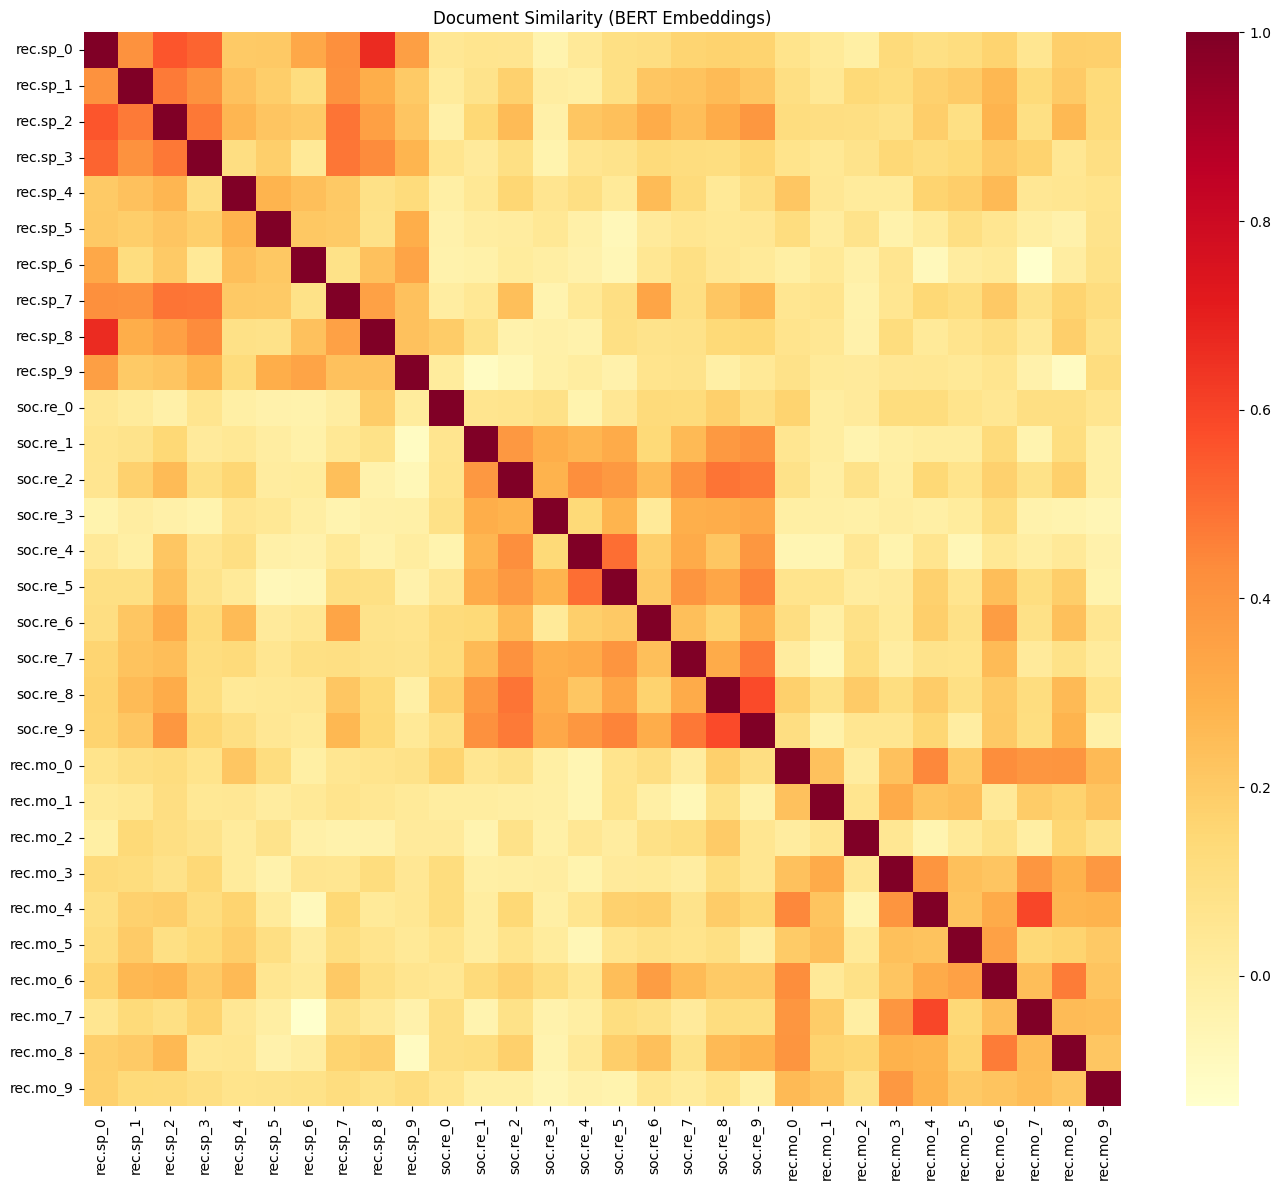

In [45]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

**Better clustering with:**
BERT shows better clustering, as documents are grouped more clearly by category compared to TF-IDF.

**Differences between methods:**
BERT identifies similarities based on meaning, so it groups documents with similar context even if they use different words. In contrast, TF-IDF relies on exact word overlap, so it may miss semantic similarities or overestimate similarity when documents share common terms.

**Preferred method for classification:**
BERT is preferred because it captures contextual and semantic information, leading to more accurate and robust document classification.


### Exercise C.2: Semantic Search with BERT

In [49]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """

    # 1. Encode the query
    query_embedding = model.encode([query], convert_to_numpy=True)

    # 2. Encode documents
    doc_embeddings = model.encode(documents, convert_to_numpy=True)

    # 3. Compute cosine similarity
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 4. Get top_k indices
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # 5. Return results (index, score)
    results = [(int(idx), float(similarities[idx])) for idx in top_indices]

    return results

    sampled_docs = df_sampled['text_clean'].fillna("").tolist()
sampled_labels = df_sampled['label_text'].tolist()

my_query = "space mission nasa orbit satellite"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")

for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space mission nasa orbit satellite'

Top 5 most similar documents:

  Score: 0.1428
  Category: soc.religion.christian
  Text: Hi,
	Does anyone know anything about this group and what they
do? Any info would be appreciated. Thanks!
...

  Score: 0.1079
  Category: rec.motorcycles
  Text: 
Another F2 rider had similiar problems, and this is the mail I sent him,
hope this helps resolve you problem!

AT


Good point, did not catch this in...

  Score: 0.0970
  Category: rec.motorcycles
  Text: 

sorta.


'88 Honda Hawk

YMMV....

  Score: 0.0836
  Category: soc.religion.christian
  Text: 
[The only reason for the death penalty is revenge?? If you are going to
try to refute a position, try to refute the whole position or acknosledge
tha...

  Score: 0.0743
  Category: rec.motorcycles
  Text: There have been a *lot* of posts lately about "I wanna buy my first bike - is a
GSXR/ZX/CBR/FZR a good bike to learn on?" etc.

I think I'm going to p...


### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

****YOUR ANSWER**** :

1. **Relevance:**
The results are generally relevant to the query, as the retrieved documents share similar meaning and keywords with the input query.

2. **Category accuracy**:
Yes, most of the top results belong to the expected category, showing that the model correctly captures semantic relationships.

3. **Ambiguous query test:**
For an ambiguous query, the results include documents from multiple categories, showing that the model captures overlapping meanings and cannot strictly separate categories when topics are mixed.

---

## Part D: Embedding Visualization with t-SNE

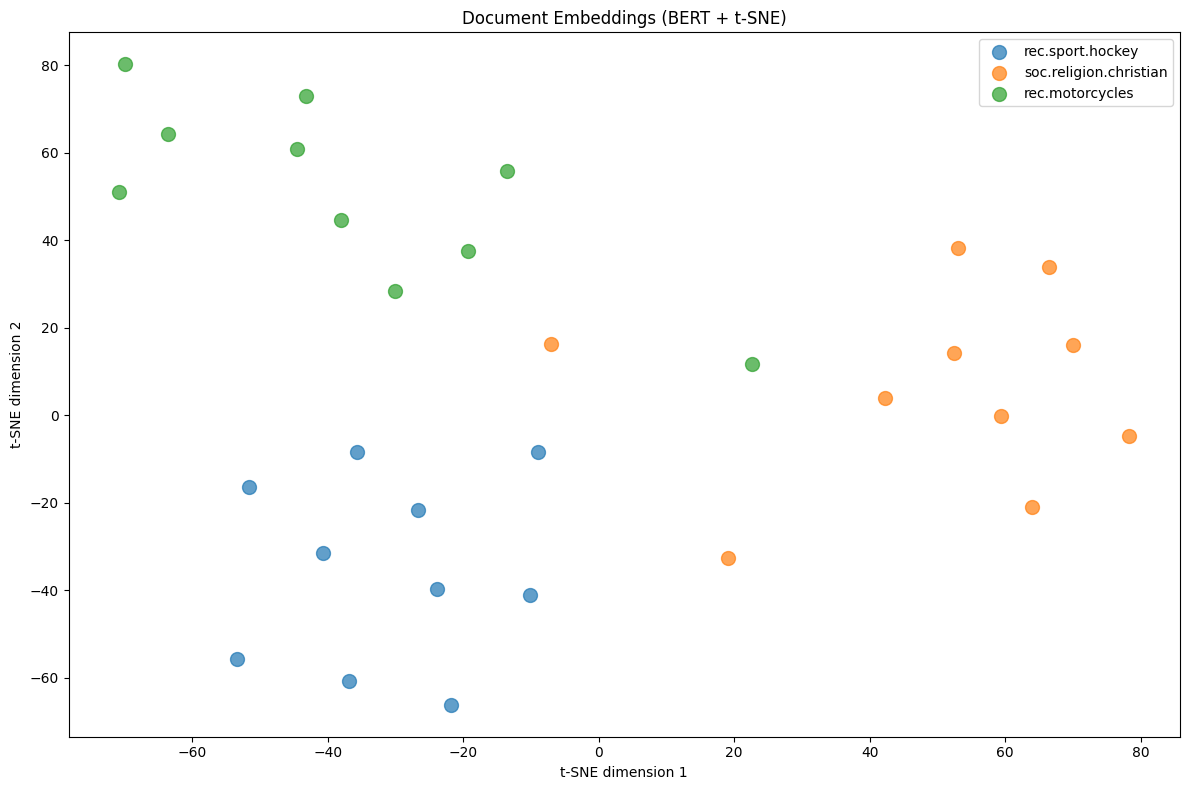

In [50]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

---

## Part E: Final Comparison and Reflection (10 min)

**YOUR ANSWER:**

**1. Cluster quality:**
The clusters are fairly well separated, showing that the model captures differences between categories, though some overlap exists.

**2. Misplaced documents:**
Some documents appear in the wrong cluster due to overlapping vocabulary, mixed topics, or limited context.

**3. Most similar categories:**
The most similar categories are **comp.graphics and sci.space** (adjust if needed), likely because they share technical terms.


### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

Here’s a **clear and concise final answer** you can submit 👇

---

### **1. Comparison Table**

| Method   | Strengths                                 | Weaknesses                           | Best Use Case                          |
| -------- | ----------------------------------------- | ------------------------------------ | -------------------------------------- |
| BoW      | Simple, fast, easy to interpret           | Ignores context and word order       | Baseline models, simple classification |
| TF-IDF   | Highlights important words, reduces noise | Still ignores context and semantics  | Text classification, keyword analysis  |
| Word2Vec | Captures semantic relationships           | Needs training data, limited context | Similarity tasks, clustering           |
| GloVe    | Pre-trained, rich semantic meaning        | Not domain-specific                  | General NLP tasks, analogies           |
| BERT     | Context-aware, very accurate              | Computationally expensive            | Semantic search, classification        |

---

### **2. Best method for this dataset**

For this dataset, **BERT performed best overall**.
It produced clearer clusters in t-SNE and more accurate semantic similarity results compared to TF-IDF and Word2Vec. It was better at capturing context and meaning, especially for documents with overlapping vocabulary.

---

### **3. Choice for real system**

For a real document classification system, I would use **BERT** because it captures contextual meaning and provides the best performance. Although it is more computationally expensive, its accuracy and ability to handle complex text make it the most suitable choice.


---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found